In [84]:
%load_ext autoreload
%autoreload 2

import pickle
import ujson
import json
import sys
import os
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
import random
import faiss

from tqdm import tqdm
from collections import defaultdict
from typing import Optional

from bioel.utils.umls_utils import UmlsMappings
from bioel.utils.bigbio_utils import CUIS_TO_REMAP, CUIS_TO_EXCLUDE, DATASET_NAMES, VALIDATION_DOCUMENT_IDS
from bioel.utils.bigbio_utils import load_bigbio_dataset, add_deabbreviations, load_dataset_df, dataset_to_documents, dataset_to_df, load_dataset_df, resolve_abbreviation, dataset_unique_tax_ids
from bioel.dataset import Dataset
from bioel.utils.solve_abbreviation.solve_abbreviations import create_abbrev

from bioel.ontology import BiomedicalOntology
from bioel.models.arboel.biencoder.data.data_utils import process_ontology
from bioel.evaluate import Evaluate

from torch.utils.data import DataLoader

from peft import PeftModel
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams
from ids import open_ai_api_key
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
from utils_functions import *

In [86]:
import openai
openai.api_key = open_ai_api_key
import re
import ujson
import logging
from collections import Counter, defaultdict
import pandas as pd

# Set up logging configuration
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logging.getLogger("httpx").setLevel(logging.WARNING)
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
device_0 = torch.device("cuda:3")
device_1 = torch.device("cuda:0")
device_2 = torch.device("cuda:1")
device_3 = torch.device("cuda:2")
sampling_params = SamplingParams(temperature=0, top_p=0.9, max_tokens=1000, stop=["<|eot_id|>"])

In [87]:
# Check how many GPUs are visible
print(f"Visible GPUs: {torch.cuda.device_count()}")

# Check if you can access both GPUs
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

seed = 40
np.random.seed(seed)
random.seed(seed)

Visible GPUs: 4
GPU 0: NVIDIA A40
GPU 1: NVIDIA A40
GPU 2: NVIDIA A40
GPU 3: Tesla V100-PCIE-32GB


In [134]:
# ##### ----------------- Load medic ----------------- #####

# dataset_name = 'ncbi_disease'
# medic_dict = {"name" : "medic",
#             "filepath" : "/mitchell/entity-linking/kbs/medic.tsv"}

# ontology2 = BiomedicalOntology.load_medic(**medic_dict)

# ##### ----------------- Load entrez ----------------- #####

dataset_name = "gnormplus" 
# dataset_name = "nlm_gene"

entrez_dict = {"name" : "entrez",
             "filepath" : "/mitchell/entity-linking/el-robustness-comparison/data/gene_info.tsv",
             "dataset" : f"{dataset_name}",}
ontology2 = BiomedicalOntology.load_entrez(**entrez_dict)

# ##### ----------------- Load MESH ----------------- #####

# dataset_name = "nlmchem"
# mesh_dict = {"name" : "mesh",
#              "filepath" : "/mitchell/entity-linking/2017AA/META/"}
# ontology2 = BiomedicalOntology.load_mesh(**mesh_dict)

##### ----------------- Load UMLS (st21pv subset) ----------------- #####

# dataset_name = "medmentions_st21pv"
# umls_dict_st21pv = {
#     "name": "umls",
#     "filepath": "/mitchell/entity-linking/2017AA/META/",
#     "path_st21pv_cui": "/home2/cye73/data_test2/arboel/medmentions_st21pv/umls_cuis_st21pv.json",
# }
# ontology2 = BiomedicalOntology.load_umls(**umls_dict_st21pv)

# # ##### ----------------- Load UMLS (full) ----------------- #####

# dataset_name = "medmentions_full"
# umls_dict = {
#     "name": "umls",
#     "filepath": "/mitchell/entity-linking/2017AA/META/",
# }
# ontology2 = BiomedicalOntology.load_umls(**umls_dict)


EL_model = "sapbert"
# EL_model = "arboel"


[2024-10-14 16:27:00] [ontology.py] [INFO] Reading entrez from /mitchell/entity-linking/el-robustness-comparison/data/gene_info.tsv
[2024-10-14 16:30:10] [bigbio_utils.py] [INFO] Number of unique tax_ids in gnormplus : 22
100%|██████████| 549545/549545 [00:02<00:00, 203401.46it/s]


In [135]:
path_to_abbrev = "/home2/cye73/data_test2/abbreviations.json"
dataset = load_bigbio_dataset(dataset_name)
dataset = add_deabbreviations(dataset, path_to_abbrev)

In [136]:
dataset_df = dataset_to_df(dataset)
test_df = dataset_df[dataset_df['split'] == 'test']
train_df = dataset_df[dataset_df['split'] == 'train']
test_df

,document_id,offsets,text,type,db_ids,split,deabbreviated_text,mention_id
0,10022127,"[[0, 9]]",TIF1gamma,[Gene],[NCBIGene:51592],test,TIF1gamma,10022127.1
7,10022127,"[[211, 220]]",TIF1gamma,[Gene],[NCBIGene:51592],test,TIF1gamma,10022127.2
8,10022127,"[[233, 242]]",TIF1alpha,[Gene],[NCBIGene:8805],test,TIF1alpha,10022127.3
9,10022127,"[[247, 255]]",TIF1beta,[Gene],[NCBIGene:10155],test,TIF1beta,10022127.4
10,10022127,"[[274, 282]]",TIF1beta,[Gene],[NCBIGene:10155],test,TIF1beta,10022127.5
...,...,...,...,...,...,...,...,...
7453,9932288,"[[606, 609]]",XT3,[Gene],[NCBIGene:54716],test,XT3,9932288.3
7454,9932288,"[[739, 742]]",XT2,[Gene],"[NCBIGene:348932, NCBIGene:22598]",test,XT2,9932288.4
7455,9932288,"[[747, 750]]",XT3,[Gene],"[NCBIGene:102680, NCBIGene:54716]",test,XT3,9932288.5
7449,9932288,"[[1139, 1142]]",XT2,[Gene],[NCBIGene:348932],test,XT2,9932288.6


In [137]:
docs = dataset_to_documents(dataset)
# docs

In [138]:
add_full_context(df = test_df, docs=docs)
add_full_context(df = train_df, docs=docs)
# test_df

/home2/cye73/llm_disambiguator/experiments/utils_functions.py:375: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["contextualized_mention"] = contextualized_mentions
/home2/cye73/llm_disambiguator/experiments/utils_functions.py:375: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["contextualized_mention"] = contextualized_mentions


In [139]:
_, TestMap_mention2context = add_context(df = test_df, docs = docs)
corpus, TrainMap_mention2context = add_context(df = train_df, docs = docs)
_, _ = add_context(df = dataset_df, docs = docs)
# dataset_df

/home2/cye73/llm_disambiguator/experiments/utils_functions.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["limited_contextualized_mention"] = limited_contextualized_mentions
/home2/cye73/llm_disambiguator/experiments/utils_functions.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["limited_contextualized_mention"] = limited_contextualized_mentions


In [140]:
# TrainMap_mention2context
# print(len(corpus))

In [141]:
# # # Load a pre-trained SentenceBERT model
# # model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# # # Generate embeddings for the corpus
# # corpus_embeddings = model.encode(corpus, convert_to_tensor=True)

# from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('princeton-nlp/sup-simcse-bert-base-uncased')
# # model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# model.to(device_0)
# # Generate embeddings for the corpus
# corpus_embeddings = model.encode(corpus, convert_to_tensor=True)

# corpus_embeddings = corpus_embeddings.cpu().detach().numpy()

In [142]:
# embedding_dimension = corpus_embeddings.shape[1]

# # Create the HNSW index with the correct arguments
# M = 32  # Number of neighbors in the HNSW graph
# index = faiss.IndexHNSWFlat(embedding_dimension, M)

# # Normalize the corpus embeddings if using cosine similarity
# faiss.normalize_L2(corpus_embeddings)

# # Add the embeddings to the index
# index.add(corpus_embeddings)

# # Print the number of sentences added to the index
# print(f"Number of sentences in the index: {index.ntotal}")

In [143]:
TrainMap_context2mention = {v: k for k, v in TrainMap_mention2context.items()}
# TrainMap_context2mention

In [144]:
# with open(f"/home/cye73/data_test2/sapbert/gnormplus/finetuned_models_nice/sapbert_gnormplus_2.json", "r") as f:
#     sapbert_res = ujson.load(f)
# sapbert_res

In [145]:
# processed_res = process_candidates_sapbert(sapbert_res)
# processed_res[0]
# sapbert_res[0]

In [146]:
# with open(f"/home2/cye73/results2/sapbert/sapbert_gnormplus_real2.json", "w") as f:
#     ujson.dump(processed_res, f, indent=4)

# Load arboel results

In [175]:
dataset_names = [f"{dataset_name}"]

model_names = [f"{EL_model}"]

eval_strategies = ['basic']

# Add paths based on the value of EL_model
path_to_result = {f"{dataset_name}": {}}

if EL_model == "arboel":
    path_to_result[dataset_name][f"{EL_model}"] = f"Candidates/{dataset_name}/{EL_model}_{dataset_name}.json"
elif EL_model == "sapbert":
    path_to_result[dataset_name][f"{EL_model}"] = f"Candidates/{dataset_name}/{EL_model}_{dataset_name}_real2.json"

evaluator = Evaluate(dataset_names=dataset_names, 
                     model_names=model_names, 
                     path_to_result=path_to_result,
                     eval_strategies=eval_strategies,
                     abbreviations_path=path_to_abbrev
                     )
evaluator.load_results()
evaluator.process_datasets()
evaluator.evaluate(
    eval_strategies=eval_strategies
                   )
# evaluator.plot_results(
#     # eval_strategies=['basic']
#     )

dataset : gnormplus, model : sapbert


  0%|          | 0/1 [00:00<?, ?it/s]

Eval Strategy: basic
gnormplus


/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
100%|██████████| 1/1 [00:00<00:00,  2.74it/s]


# ACCURACY

In [176]:
# device_1 = torch.device("cuda:0")
# device_2 = torch.device("cuda:1")

# llm = LLM(
# model=model1,
# tensor_parallel_size=1,
# device=device_1)

# llm2 = LLM(
# model=model2,
# tensor_parallel_size=1,
# device=device_2)

In [177]:
# results = evaluator.full_results["basic"][f"{dataset_name}"]
# results

In [178]:

number_candidates = 50
results = evaluator.full_results["basic"][f"{dataset_name}"]

# Base columns common to all models
base_cols = ['document_id', 'offsets', 'text', 'deabbreviated_text', 'db_ids', 'mention_id', 'joined_offsets']

# Add model-specific columns based on EL_model
if EL_model == "arboel":
    model_cols = ['arboel_resolve_abbrev', 'arboel_resolve_abbrev_min_hit_index']
    rename_map = {
        'arboel_resolve_abbrev': 'arboel_candidates',
        'arboel_resolve_abbrev_min_hit_index': 'arboel_hit_index'
    }
elif EL_model == "sapbert":
    model_cols = ['sapbert_resolve_abbrev', 'sapbert_resolve_abbrev_min_hit_index']
    rename_map = {
        'sapbert_resolve_abbrev': 'sapbert_candidates',
        'sapbert_resolve_abbrev_min_hit_index': 'sapbert_hit_index'
    }

# Combine base and model-specific columns
cols = base_cols + model_cols
# Select and rename columns in results
filtered_results = results[cols].rename(columns=rename_map)
# Filter results based on hit index
filtered_results = filtered_results[filtered_results[f'{EL_model}_hit_index'] < number_candidates]

# filtered_results = filtered_results.iloc[:500]
filtered_results

,document_id,offsets,text,deabbreviated_text,db_ids,mention_id,joined_offsets,sapbert_candidates,sapbert_hit_index
0,10022127,"[[0, 9]]",TIF1gamma,TIF1gamma,[NCBIGene:51592],10022127.1,"0,9","[[NCBIGene:733198], [NCBIGene:734959], [NCBIGe...",3
1,10022127,"[[211, 220]]",TIF1gamma,TIF1gamma,[NCBIGene:51592],10022127.2,"211,220","[[NCBIGene:733198], [NCBIGene:734959], [NCBIGe...",3
2,10022127,"[[233, 242]]",TIF1alpha,TIF1alpha,[NCBIGene:8805],10022127.3,"233,242","[[NCBIGene:495130], [NCBIGene:108704369], [NCB...",3
3,10022127,"[[247, 255]]",TIF1beta,TIF1beta,[NCBIGene:10155],10022127.4,"247,255","[[NCBIGene:10155], [NCBIGene:21849], [NCBIGene...",0
4,10022127,"[[274, 282]]",TIF1beta,TIF1beta,[NCBIGene:10155],10022127.5,"274,282","[[NCBIGene:10155], [NCBIGene:21849], [NCBIGene...",0
...,...,...,...,...,...,...,...,...,...
3217,9932288,"[[606, 609]]",XT3,XT3,[NCBIGene:54716],9932288.3,"606,609","[[NCBIGene:54716], [NCBIGene:22599], [NCBIGene...",0
3218,9932288,"[[739, 742]]",XT2,XT2,"[NCBIGene:348932, NCBIGene:22598]",9932288.4,"739,742","[[NCBIGene:827940], [NCBIGene:64132], [NCBIGen...",2
3219,9932288,"[[747, 750]]",XT3,XT3,"[NCBIGene:102680, NCBIGene:54716]",9932288.5,"747,750","[[NCBIGene:54716], [NCBIGene:22599], [NCBIGene...",0
3220,9932288,"[[1139, 1142]]",XT2,XT2,[NCBIGene:348932],9932288.6,"1139,1142","[[NCBIGene:827940], [NCBIGene:64132], [NCBIGen...",39


# ACCURACY

In [179]:
# new_res = filtered_results[(filtered_results['sapbert_hit_index']!=0) & 
#                            (filtered_results['sapbert_hit_index']>filtered_results['arboel_hit_index'])&
#                            (filtered_results['sapbert_hit_index'] < 64)]
# new_res

In [180]:
# cands = ["MESH:D003919", "MESH:D003923", "MESH:D011254","MESH:D048909","MESH:C564219","MESH:D006029","MESH:C562774","MESH:C565632","MESH:C563322"]
# cands2 = ["MESH:D020790", "MESH:D018500", "MESH:D003919"]

# for cand in cands :
#     print(f"{cand} :", ontology2.entities[cand].name)
# print("--------")
# for cand in cands2 :
#     print(f"{cand} :", ontology2.entities[cand].name)


In [181]:
total_mentions = len(results)
total_mentions

3222

# Part with GPT

### Train set

In [182]:

train_mentions = []
train_mention2context = {}
train_mention2gold = {}
train_mention2text = {}
for idx, row in train_df.iterrows():
    train_mention2gold[row['mention_id']] = row['db_ids']
    train_mentions.append(row['mention_id'])
    train_mention2text[row['mention_id']] = row['deabbreviated_text']
    train_mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

# train_mention2gold

### Test set

In [183]:
mention2context = {}
for idx, row in test_df.iterrows():
    mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

mentions = []
mention2biencoder_candidates = {}
mention2arboel_candidates = {}
mention2sapbert_candidates = defaultdict(list)
mention2gold = {}
mention2hit = {}
mention2text = {}
cui2name = {}
for idx, row in filtered_results.iterrows():
    # Only consider row if hit_index < max number of candidates
    if row[f'{EL_model}_hit_index'] < number_candidates:
        if EL_model == "arboel":
            mention2arboel_candidates[row['mention_id']] = [el[0] for el in row['arboel_candidates'][:number_candidates]]
        
        elif EL_model == "sapbert":
            mention2sapbert_candidates[row['mention_id']] = [el[0] for el in row['sapbert_candidates'][:number_candidates]] 
        
        mention2gold[row['mention_id']] = row['db_ids']
        mentions.append(row['mention_id'])
        mention2text[row['mention_id']] = row['deabbreviated_text']    
        mention2hit[row['mention_id']] = row[f'{EL_model}_hit_index']

In [184]:

number_hits_arboel = 0
number_hits_sapbert = 0

if EL_model == "arboel":
    number_hits_arboel = number_hit(
        mention2arboel_candidates, mention2gold, number_candidates
    )
    print("number hits arboel :", number_hits_arboel)
    arboel_results = compute_recall(number_hits_arboel, number_candidates, total_mentions)
    print("arboel:")
    for i, (unnormalized, normalized) in enumerate(arboel_results[:10]):
        print(
            f"recall {i+1}: Normalized = {normalized:.4f}, Unnormalized = {unnormalized:.4f}"
        )

elif EL_model == "sapbert":
    number_hits_sapbert = number_hit(
        mention2sapbert_candidates, mention2gold, number_candidates
    )
    print("number hits sapbert :", number_hits_sapbert)

    sapbert_results = compute_recall(number_hits_sapbert, number_candidates, total_mentions)
    print("Sapbert:")
    for i, (unnormalized, normalized) in enumerate(sapbert_results[:10]):
        print(
            f"recall {i+1}: Normalized = {normalized:.4f}, Unnormalized = {unnormalized:.4f}"
        )

number hits sapbert : {1: 612, 2: 214, 3: 192, 4: 367, 5: 431, 6: 311, 7: 150, 8: 155, 9: 76, 10: 83, 11: 27, 12: 14, 13: 16, 14: 11, 15: 10, 16: 20, 17: 32, 18: 8, 19: 14, 20: 28, 21: 10, 22: 17, 23: 11, 24: 1, 25: 4, 26: 2, 27: 3, 28: 8, 29: 5, 30: 2, 31: 6, 32: 16, 33: 0, 34: 0, 35: 0, 36: 2, 37: 11, 38: 0, 39: 0, 40: 4, 41: 3, 42: 1, 43: 1, 44: 1, 45: 0, 46: 7, 47: 0, 48: 0, 49: 1, 50: 1}
Sapbert:
recall 1: Normalized = 0.2119, Unnormalized = 0.1899
recall 2: Normalized = 0.2860, Unnormalized = 0.2564
recall 3: Normalized = 0.3525, Unnormalized = 0.3160
recall 4: Normalized = 0.4796, Unnormalized = 0.4299
recall 5: Normalized = 0.6288, Unnormalized = 0.5636
recall 6: Normalized = 0.7365, Unnormalized = 0.6601
recall 7: Normalized = 0.7884, Unnormalized = 0.7067
recall 8: Normalized = 0.8421, Unnormalized = 0.7548
recall 9: Normalized = 0.8684, Unnormalized = 0.7784
recall 10: Normalized = 0.8972, Unnormalized = 0.8042


In [185]:
system_instructions = """You are a professional data annotator and curator.
Your task is to identify the correct entity for a given mention based on the provided context and the descriptions of {number_candidates} candidate entities."""

system_instructions_recall = """You are a professional data annotator and curator.
Your task is to rank the candidate entities from best to worst for a given mention based on the provided context and the descriptions of each candidate entities."""


### Add entities to candidates (it didn't work)

In [186]:
# entities_cui = list(ontology2.entities)
# entities_cui2data = get_candidates_data_v2(entities_cui, ontology2)
# entities_data2cui = {v: k for k, v in entities_cui2data.items()}
# entities_data2cui
# entities_data = list(entities_cui2data.values())
# entities_data

In [187]:
# from sentence_transformers import SentenceTransformer

# model = SentenceTransformer('princeton-nlp/sup-simcse-bert-base-uncased')
# # model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# # from transformers import AutoModel
# # model = AutoModel.from_pretrained('nvidia/NV-Embed-v1', trust_remote_code=False)
# # model.to(device_1)

# # Generate embeddings for the corpus
# entities_embeddings = model.encode(entities_data, convert_to_tensor=True)

# entities_embeddings = entities_embeddings.cpu().detach().numpy()

# embedding_dimension = entities_embeddings.shape[1]

# # Create the HNSW index with the correct arguments
# M = 32  # Number of neighbors in the HNSW graph
# index_ent = faiss.IndexHNSWFlat(embedding_dimension, M)

# # Normalize the corpus embeddings if using cosine similarity
# faiss.normalize_L2(entities_embeddings)

# # Add the embeddings to the index
# index_ent.add(entities_embeddings)

# # Print the number of sentences added to the index
# print(f"Number of sentences in the index: {index_ent.ntotal}")

In [188]:
# mention = "9973276.8"

# text = mention2text[mention]
# context = mention2context[mention]

# topk = topk_entities(model = model,
#               index_entity=index_ent,
#               query=context,
#               entity_corpus = entities_data,
#               entities_data2cui = entities_data2cui,
#               k=10,
#               )

# data = get_candidates_data(mention2gold[mention], ontology2)


# print("Mention ID :", mention)
# print("Text :", text)
# for i, entity_cui in enumerate(topk):
#     print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
# print("Gold CUI :", mention2gold[mention], "Name:", data)

In [62]:
# total_hits = 0
# for i, mention_id in enumerate(mentions):
#     gold_cui = mention2gold[mention_id][0]
#     candidates = mention2arboel_candidates[mention_id][:5]
#     if gold_cui in candidates:
#         total_hits += 1
# total_hits

In [63]:
# total_hits = 0
# for i, mention_id in enumerate(mentions):
#     text = mention2text[mention_id]
#     context = mention2context[mention_id]

#     topk = topk_entities(model = model,
#                 index_entity=index_ent,
#                 query=context,
#                 entity_corpus = entities_data,
#                 entities_data2cui = entities_data2cui,
#                 k=5,
#                 )

#     data = get_candidates_data(mention2gold[mention_id], ontology2)
#     gold_cui = mention2gold[mention_id][0]
    
#     candidates = list(set(mention2arboel_candidates[mention_id][:5] + topk))
#     if gold_cui in candidates:
#         total_hits += 1
        
#     # if i < 2 :
#     #     print("Text :", text)
#     #     for i, entity_cui in enumerate(topk):
#     #         print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
#     #     print("Gold CUI :", mention2gold[mention], "Name:", data)

In [64]:
# total_hits

In [65]:
# hit = defaultdict(int)
# for i, mention in enumerate(mentions):
#     text = mention2text[mention]
#     context = mention2context[mention]

#     topk = topk_entities(model = model,
#                 index_entity=index_ent,
#                 query=text,
#                 entity_corpus = entities_data,
#                 entities_data2cui = entities_data2cui,
#                 k=1000,
#                 )

#     data = get_candidates_data(mention2gold[mention], ontology2)
#     gold_cui = list(data.keys())[0]
    
#     if gold_cui in topk:
#         ind = topk.index(gold_cui)
#         hit[ind] += 1
        
#     # if i < 2 :
#     #     print("Text :", text)
#     #     for i, entity_cui in enumerate(topk):
#     #         print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
#     #     print("Gold CUI :", mention2gold[mention], "Name:", data)

In [66]:
# print("Numbers of hit:", sum(hit.values()))
# print(hit)

In [67]:
# sorted_hits = sorted(hit.keys())
# sorted_hit_dict = {key: hit[key] for key in sorted_hits}
# print(sorted_hit_dict)

### Single prompt for error analysis

In [68]:
# # mention = '9931324.9' # "9973276.8"
# mention_id = "9288106.17"
# # i = 39
# # mention = mentions[i]
# mention_name = mention2text[mention_id]
# context = mention2context[mention_id]
# candidates = get_candidates_data(candidates = mention2biencoder_candidates[mention_id], 
#                                  ontology = ontology2)
# topk = topk_examples(model = model,
#                     index = index,
#                     query=context, 
#                     corpus=corpus, 
#                     TrainMap_context2mention=TrainMap_context2mention, 
#                     train_mention2text=train_mention2text, 
#                     train_mention2gold=train_mention2gold, 
#                     ontology=ontology2, 
#                     k=3)
# # random.shuffle(candidates)
# # candidates = get_candidates_data_v2(mention2candidates[mentions[i]])

# text = generate_prompt_text(
#             mention=mention_name,
#             context=context,
#             candidates=candidates,
#             topk_examples=topk,
#             reasoning=False,
#             recall=False,
#             recall_k=5,
#             analysis_version="v1",
#             analysis=None,
#             mention_id=mention_id,
#         )

# pred_cui = prompt_gpt(prompt=text,
#                       system_instructions=system_instructions, 
#                       gpt_version = "gpt-4o-mini")
# # model = "gpt-3.5-turbo-0125"
# # model = "gpt-4o-2024-08-06"
# print("Mention ID :", mention)
# print("Context :", context)
# print("Top k examples :", topk)
# print("Text :", text)
# print("Gold CUI :", mention2gold[mention])

# print("Predicted CUI :", pred_cui)

In [69]:
# results = evaluate_vllm(llm = "gpt-4o-mini",
#                     nlp_model=model,
#                     tokenizer=None,
#                     index=index,
#                     system_instructions=system_instructions,
#                     ontology=ontology2, 
#                     mentions=mentions[:5], 
#                     corpus=corpus,
#                     mention2text=mention2text,
#                     mention2context=mention2context,
#                     mention2biencoder_candidates=mention2biencoder_candidates,   
#                     TrainMap_context2mention=TrainMap_context2mention,
#                     train_mention2text=train_mention2text,
#                     train_mention2gold=train_mention2gold,
#                     k=3, 
#                     sampling_params=None,
#                     reasoning=False,
#                     analysis=None,
#                     analysis_version="v1",
#                     recall=False,
#                     recall_k=5,)
# results

In [ ]:
score = scoring(results=results, mention2gold=mention2gold)
score


In [ ]:
### SAVE THE RESULTS ! IT'S EXPENSIVE TO RUN THE MODEL !!!

# with open("gpt4o_results.json", "w") as f:
#     json.dump(results, f, indent=4)

with open("gpt4o_results.json", "r") as f:
    results = json.load(f)

# results

In [ ]:
error_mentions = error_analysis(results = results, 
                                ontology = ontology2, 
                                mention2gold = mention2gold, 
                                mention2context = mention2context)
error_mentions

# Evaluation with Mixtral

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

mixtral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
mixtral_model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")


### ICL

In [44]:
def prompt_mistral(mention, context, candidates, topk_examples):
    ''' 
    Equivalent of the prompt function for the Mistral model.
    '''
    
    prompt_text = f"""
    You are a professional data annotator and curator.
    Your task is to identify the correct entity for a given mention based on the provided context and the descriptions of {number_candidates} candidate entities. \n
    
    Here are a few examples : \n
    {topk_examples} \n

    This is the specific mention that needs to be linked to the correct entity : {mention} \n
    
    This is the context where the mention appears : \n
    {context} \n
    
    These are the candidate entities to choose from: \n
    {candidates} \n
    
    You must provide an answer among the candidates. \n
    
    Return the answer in the following format : CUI
    Do not add any explanations!
    """

    # Tokenize input
    inputs = mixtral_tokenizer(prompt_text, return_tensors="pt", max_length=2048, truncation=True)

    # Generate output (you can adjust `max_new_tokens` to limit the output)
    with torch.no_grad():
        outputs = mixtral_model.generate(**inputs, max_new_tokens=300, temperature=0.0)

    # Decode the generated tokens
    generated_text = mixtral_tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract the CUI answer (since the model generates the entire text, you might need to clean it)
    return generated_text.strip()

In [ ]:
# mention = '9931324.9' # "9973276.8"
mention = "9888388.6"
# i = 39
# mention = mentions[i]
text = mention2text[mention]
context = mention2context[mention]
candidates = get_candidates_data(candidates=mention2biencoder_candidates[mention], 
                                 ontology=ontology2)
topk = topk_examples(query=context, 
                        corpus=corpus, 
                        TrainMap_context2mention=TrainMap_context2mention, 
                        train_mention2text=train_mention2text, 
                        train_mention2gold=train_mention2gold, 
                        ontology=ontology2, 
                        k=3)

pred_cui = prompt_mistral(text, context, candidates, topk_examples=topk)

print("Predicted CUI :", pred_cui)

# Flan T5 model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load Flan-T5 model and tokenizer
flan_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-xxl")
flan_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-xxl")


In [29]:
def prompt_flan_t5(mention, context, candidates, topk_examples):
    prompt_text = f"""
    You are a professional data annotator and curator.
    Your task is to identify the correct entity for a given mention based on the provided context and the descriptions of 64 candidate entities.

    Here are a few examples: \n
    {topk_examples} \n

    This is the specific mention that needs to be linked to the correct entity: {mention} \n

    This is the context where the mention appears : \n
    {context} \n
    
    These are the candidate entities to choose from: \n
    {candidates} \n
    
    You must provide an answer among the candidates. \n

    Return the answer in the following format: CUI
    Do not add any explanations!
    """

    inputs = flan_tokenizer(prompt_text, return_tensors="pt", max_length=2048, truncation=True)

    outputs = flan_model.generate(**inputs, max_new_tokens=100, temperature=0.0)
    generated_text = flan_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated_text.strip()


In [ ]:
mention = "9988281.10"
text = mention2text[mention]
context = mention2context[mention]
candidates = get_candidates_data(mention2biencoder_candidates[mention], ontology2)
topk = topk_examples(query=context, 
                        corpus=corpus, 
                        TrainMap_context2mention=TrainMap_context2mention, 
                        train_mention2text=train_mention2text, 
                        train_mention2gold=train_mention2gold, 
                        ontology=ontology2, 
                        k=3)

pred_cui = prompt_flan_t5(mention = text, context = context, candidates=candidates, topk_examples=topk)

print("Mention ID :", mention)
print("Context :", context)
print("Top k examples :", topk)
print("Text :", mention2text[mention])
print("Gold CUI :", mention2gold[mention])
print("Predicted CUI :", pred_cui)

In [ ]:
CUIs = [v[0] for k, v in mention2gold.items()] # List of all gold CUIs from the test set (reduced one = only with hit_index < nb_candidates)

cui2name = get_candidates_name(CUIs, ontology2)
name2cui = {v: k for k, v in cui2name.items()}

name2cui[pred_cui]

# vllm
# LLAMA
Llama-3.1-8B-UltraMedical (71%)

Bio-Medical-Llama-3-8B (41%)

Laim/Llama-3.1-MedPalm2-imitate-8B-Instruct (17%)

meta-llama/Meta-Llama-3.1-8B-Instruct (79%) (91% for k=10)

mistralai/Mistral-7B-Instruct-v0.3 (82%) (84% for k=10)

mistralai/Mistral-Nemo-Instruct-2407 (90%)

ISTA-DASLab/Mixtral-8x7B-Instruct-v0_1-AQLM-2Bit-1x16-hf

In [29]:
# llm = LLM(
#     model="meta-llama/Meta-Llama-3.1-8B-Instruct",
#     enforce_eager=True,
# )

llm = LLM(
model="Qwen/Qwen2.5-7B-Instruct",
tensor_parallel_size=1,
dtype = "half",
gpu_memory_utilization=0.8,
max_logprobs=1000,
device=device_1,
max_model_len = 30000)

tokenizer = llm.get_tokenizer()

WARNING 10-03 11:56:07 config.py:1651] Casting torch.bfloat16 to torch.float16.
WARNING 10-03 11:56:07 config.py:365] Async output processing is only supported for CUDA or TPU. Disabling it for other platforms.
INFO 10-03 11:56:07 llm_engine.py:213] Initializing an LLM engine (v0.6.0) with config: model='Qwen/Qwen2.5-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=30000, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda:0, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collec

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:01<00:04,  1.43s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:02<00:02,  1.44s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:04<00:01,  1.47s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.50s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.48s/it]



INFO 10-03 11:56:18 model_runner.py:926] Loading model weights took 14.2487 GB
INFO 10-03 11:56:24 gpu_executor.py:122] # GPU blocks: 19754, # CPU blocks: 4681
INFO 10-03 11:56:29 model_runner.py:1217] Capturing the model for CUDA graphs. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 10-03 11:56:29 model_runner.py:1221] CUDA graphs can take additional 1~3 GiB memory per GPU. If you are running out of memory, consider decreasing `gpu_memory_utilization` or enforcing eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.
INFO 10-03 11:58:51 model_runner.py:1335] Graph capturing finished in 143 secs.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [9]:
# # !pip uninstall xformers -y
# # !pip install xformers==0.0.27.post1
# !pip install xformers==0.0.29.dev921

In [27]:
# llm2 = LLM(
# model="mistralai/Mistral-7B-Instruct-v0.3",
# tensor_parallel_size=1,
# dtype = "half",
# gpu_memory_utilization=0.9,
# max_logprobs=1000,
# device=device_2)

In [28]:
# torch.cuda.set_device(0)
# torch.cuda.empty_cache()

In [31]:
# mentions

In [43]:
mention_id = "25847295.1"
mention_name = mention2text[mention_id]
context = mention2context[mention_id]
candidates = get_candidates_data(mention2sapbert_candidates[mention_id], ontology2)
topk = topk_examples(model = model, # sentence transformer model
                    index=index,
                    query=context,
                    corpus=corpus,
                    TrainMap_context2mention=TrainMap_context2mention,
                    train_mention2text=train_mention2text,
                    train_mention2gold=train_mention2gold,
                    ontology=ontology2,
                    k=3)

prompt = generate_prompt_text(mention = mention_name,
                              context=context,
                              candidates=candidates,
                              topk_examples=topk,
                              recall=False,
                              recall_k=5,
                              mention_id=mention_id)

# Generate the prediction using the open source
pred_cui = prompt_vllm(prompt = prompt,
                       system_instructions=system_instructions,
                       llm=llm,
                       tokenizer=tokenizer,
                       sampling_params=sampling_params)
answer = extract_last_cui(pred_cui)

# Output the results
print("Mention ID:", mention_id)
print("Context:", context)
print("Top k examples:", topk)
print("Text:", mention2text[mention_id])
print("Gold CUI:", mention2gold[mention_id])
print("Predicted CUI:", pred_cui)
print("Final answer :", answer)

Batches: 100%|██████████| 1/1 [00:00<00:00, 60.38it/s]


(1, 768)


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s, est. speed input: 3339.58 toks/s, output: 20.39 toks/s]

Mention ID: 25847295.1
Context: Nonylphenol diethoxylate inhibits [ENTITY_START] apoptosis [ENTITY_END] induced in PC12 cells Nonylphenol and short-chain nonylphenol ethoxylates such as NP2 EO are present in aquatic environment as wastewater contaminants, and their toxic effects on aquatic species have been reported.
Top k examples: Mention 1: Coumarin || Context: biogas production, adverse effects on microorganisms driving the anaerobic digestion process are expected. Furthermore, coumarin derivatives like warfarin, which are used as anti-coagulating medicine, are found in wastewater affecting its treatment. [ENTITY_START] Coumarin [ENTITY_END] as the structure common to all coumarins inhibits the anaerobic digestion process. However, details of this inhibition are still elusive. Here, we studied the impact of coumarin on acetogenesis and methanogenesis. || Correct CUI: {'UMLS:C0010206': {'cui': 'UMLS:C0010206', 'name': 'coumarin', 'types': array(['T109', 'T121'], dtype=object), 'alia

In [32]:
print(prompt)


    Here are a few examples:
Mention 1: Coumarin || Context: biogas production, adverse effects on microorganisms driving the anaerobic digestion process are expected. Furthermore, coumarin derivatives like warfarin, which are used as anti-coagulating medicine, are found in wastewater affecting its treatment. [ENTITY_START] Coumarin [ENTITY_END] as the structure common to all coumarins inhibits the anaerobic digestion process. However, details of this inhibition are still elusive. Here, we studied the impact of coumarin on acetogenesis and methanogenesis. || Correct CUI: {'UMLS:C0010206': {'cui': 'UMLS:C0010206', 'name': 'coumarin', 'types': array(['T109', 'T121'], dtype=object), 'aliases': ['1,2-benzopyrone', 'Chromen-2-one', 'Cumarin', 'Coumarin anticoagulant (product)', 'Coumarin anticoagulant', 'Tonka bean camphor', 'Coumarinic anhydride (substance)', 'Coumarin', 'Tonka Bean Camphor', '5,6-benzo-alpha-pyrone', 'alpha benzopyrone', 'COUMARIN', 'Coumarinic anhydride', '2H-1-Benzopyr

In [ ]:
# results = evaluate(llm=llm,
#                     nlp_model=model,
#                     tokenizer=tokenizer,
#                     index=index,
#                     system_instructions=system_instructions,
#                     mentions=mentions,
#                     ontology=ontology2,
#                     corpus=corpus,
#                     mention2context=mention2context,
#                     mention2biencoder_candidates=mention2biencoder_candidates,
#                     mention2text=mention2text,
#                     TrainMap_context2mention=TrainMap_context2mention,
#                     train_mention2text=train_mention2text,
#                     train_mention2gold=train_mention2gold,
#                     k=3,
#                     sampling_params=sampling_params)
# results

In [ ]:
# score = scoring(results=results, 
#                 mention2gold=mention2gold)
# score

## Result : With reasoning

In [28]:
### SAVE THE RESULTS (It's long to run the model 26mins)
    
# with open("Meta-Llama-3.1-8B-Instruct_k=10_reasoning_results.json", "w") as f:
#     json.dump(results, f, indent=4)

with open("data/biencoder/reasoning2/Meta-Llama-3.1-8B-Instruct_k=3_reasoning_results.json", "r") as f:
    results1r = json.load(f)
    
with open("data/biencoder/reasoning2/Meta-Llama-3.1-8B-Instruct_k=5_reasoning_results.json", "r") as f:
    results2r = json.load(f)
    
with open("data/biencoder/reasoning2/Meta-Llama-3.1-8B-Instruct_k=10_reasoning_results.json", "r") as f:
    results3r = json.load(f)
    
    
###############################################################  
with open("data/biencoder/reasoning2/Mistral-7B-Instruct-v0.3_k=3_reasoning_results.json", "r") as f:
    results4r = json.load(f)

with open("data/biencoder/reasoning2/Mistral-7B-Instruct-v0.3_k=5_reasoning_results.json", "r") as f:
    results5r = json.load(f)
    
with open("data/biencoder/reasoning2/Mistral-7B-Instruct-v0.3_k=10_reasoning_results.json", "r") as f:
    results6r = json.load(f)


###############################################################
with open("data/biencoder/reasoning2/Mistral-Nemo-Instruct-2407_k=3_reasoning_results.json", "r") as f:
    results7r = json.load(f)

with open("data/biencoder/reasoning2/Mistral-Nemo-Instruct-2407_k=5_reasoning_results.json", "r") as f:
    results8r = json.load(f)

with open("data/biencoder/reasoning2/Mistral-Nemo-Instruct-2407_k=10_reasoning_results.json", "r") as f:
    results9r = json.load(f)
    
    
###############################################################
with open("data/biencoder/reasoning2/Qwen2.5-7B-Instruct_k=3_reasoning_results.json", "r") as f:
    results10r = json.load(f)

# with open("data/biencoder/reasoning2/Qwen2.5-7B-Instruct_k=5_reasoning_results.json", "r") as f:
#     results11r = json.load(f)

# with open("data/biencoder/reasoning2/Qwen2.5-7B-Instruct_k=10_reasoning_results.json", "r") as f:
#     results12r = json.load(f)
    
    
###############################################################
with open("data/biencoder/reasoning2/Qwen2.5-14B-Instruct_k=3_reasoning_results.json", "r") as f:
    results13r = json.load(f)

# with open("data/biencoder/reasoning2/Qwen2.5-14B-Instruct_k=5_reasoning_results.json", "r") as f:
#     results14r = json.load(f)

# with open("data/biencoder/reasoning2/Qwen2.5-14B-Instruct_k=10_reasoning_results.json", "r") as f:
#     results15r = json.load(f)

In [ ]:
# for mention_id in results.copy() :
#     if results[mention_id] is None:
#         del results[mention_id]

score1r = scoring(results = results1r, mention2gold = mention2gold)
print("Meta-Llama-3.1-8B-Instruct_k=3_reasoning_results :", score1r)
score2r = scoring(results = results2r, mention2gold = mention2gold)
print("Meta-Llama-3.1-8B-Instruct_k=5_reasoning_results:", score2r)
score3r = scoring(results = results3r, mention2gold = mention2gold)
print("Meta-Llama-3.1-8B-Instruct_k=10_reasoning_results:", score3r)

print("---------------------------------")

score4r = scoring(results = results4r, mention2gold = mention2gold)
print("Mistral-7B-Instruct-v0.3_k=3_reasoning_results :", score4r)
score5r = scoring(results = results5r, mention2gold = mention2gold)
print("Mistral-7B-Instruct-v0.3_k=5_reasoning_results :", score5r)
score6r = scoring(results = results6r, mention2gold = mention2gold)
print("Mistral-7B-Instruct-v0.3_k=10_reasoning_results :", score6r)

print("---------------------------------")

score7r = scoring(results = results7r, mention2gold = mention2gold)
print("Mistral-Nemo-Instruct-2407_k=3_reasoning_results :", score7r)
score8r = scoring(results = results8r, mention2gold = mention2gold)
print("Mistral-Nemo-Instruct-2407_k=5_reasoning_results:", score8r)
score9r = scoring(results = results9r, mention2gold = mention2gold)
print("Mistral-Nemo-Instruct-2407_k=10_reasoning_results:", score9r)

print("---------------------------------")

score10r = scoring(results = results10r, mention2gold = mention2gold)
print("Qwen2.5-7B-Instruct_k=3_results :", score10r)
# score11r = scoring(results = results11r, mention2gold = mention2gold)
# print("Qwen2.5-7B-Instruct_k=5_results:", score11r)
# score12r = scoring(results = results12r, mention2gold = mention2gold)
# print("Qwen2.5-7B-Instruct_k=10_results:", score12r)

print("---------------------------------")

score13r = scoring(results = results13r, mention2gold = mention2gold)
print("Qwen2.5-14B-Instruct_k=3_results :", score13r)
# score14r = scoring(results = results14r, mention2gold = mention2gold)
# print("Qwen2.5-14B-Instruct_k=5_results:", score14r)
# score15r = scoring(results = results15r, mention2gold = mention2gold)
# print("Qwen2.5-14B-Instruct_k=10_results:", score15r)

In [ ]:
error_mentions = error_analysis(results = results13r, 
                                ontology = ontology2, 
                                mention2gold = mention2gold, 
                                mention2context = mention2context)
error_mentions

In [ ]:
mention_id = '9988281.10'
print(results13r[mention_id]["explanation"])

## Result : Without reasoning

In [32]:
# with open("data/biencoder/default2/Meta-Llama-3.1-8B-Instruct_k=3_results.json", "r") as f:
#     results1 = json.load(f)
    
# with open("data/biencoder/default2/Meta-Llama-3.1-8B-Instruct_k=5_results.json", "r") as f:
#     results2 = json.load(f)
    
# with open("data/biencoder/default2/Meta-Llama-3.1-8B-Instruct_k=10_results.json", "r") as f:
#     results3 = json.load(f)
    
    
# ###############################################################  
# with open("data/biencoder/default2/Mistral-7B-Instruct-v0.3_k=3_results.json", "r") as f:
#     results4 = json.load(f)

# with open("data/biencoder/default2/Mistral-7B-Instruct-v0.3_k=5_results.json", "r") as f:
#     results5 = json.load(f)
    
# with open("data/biencoder/default2/Mistral-7B-Instruct-v0.3_k=10_results.json", "r") as f:
#     results6 = json.load(f)


# ###############################################################
# with open("data/biencoder/default2/Mistral-Nemo-Instruct-2407_k=3_results.json", "r") as f:
#     results7 = json.load(f)

# with open("data/biencoder/default2/Mistral-Nemo-Instruct-2407_k=5_results.json", "r") as f:
#     results8 = json.load(f)

# with open("data/biencoder/default2/Mistral-Nemo-Instruct-2407_k=10_results.json", "r") as f:
#     results9 = json.load(f)
    
# ###############################################################
# with open("data/biencoder/default2/Qwen2.5-7B-Instruct_k=3_results.json", "r") as f:
#     results10 = json.load(f)

# with open("data/biencoder/default2/Qwen2.5-7B-Instruct_k=5_results.json", "r") as f:
#     results11 = json.load(f)

# with open("data/biencoder/default2/Qwen2.5-7B-Instruct_k=10_results.json", "r") as f:
#     results12 = json.load(f)
    
    
# ###############################################################
# with open("data/biencoder/default2/Qwen2.5-14B-Instruct_k=3_results.json", "r") as f:
#     results13 = json.load(f)

# with open("data/biencoder/default2/Qwen2.5-14B-Instruct_k=5_results.json", "r") as f:
#     results14 = json.load(f)

# with open("data/biencoder/default2/Qwen2.5-14B-Instruct_k=10_results.json", "r") as f:
#     results15 = json.load(f)

In [ ]:
# score1 = scoring(results = results1, mention2gold = mention2gold)
# print("data/default/Meta-Llama-3.1-8B-Instruct_k=3_results :", score1)
# score2 = scoring(results = results2, mention2gold = mention2gold)
# print("data/default/Meta-Llama-3.1-8B-Instruct_k=5_results:", score2)
# score3 = scoring(results = results3, mention2gold = mention2gold)
# print("data/default/Meta-Llama-3.1-8B-Instruct_k=10_results:", score3)

# print("---------------------------------")

# score4 = scoring(results = results4, mention2gold = mention2gold)
# print("data/default/Mistral-7B-Instruct-v0.3_k=3_results :", score4)
# score5 = scoring(results = results5, mention2gold = mention2gold)
# print("data/default/Mistral-7B-Instruct-v0.3_k=5_results :", score5)
# score6 = scoring(results = results6, mention2gold = mention2gold)
# print("data/default/Mistral-7B-Instruct-v0.3_k=10_results :", score6)

# print("---------------------------------")

# score7 = scoring(results = results7, mention2gold = mention2gold)
# print("data/default/Mistral-Nemo-Instruct-2407_k=3_results :", score7)
# score8 = scoring(results = results8, mention2gold = mention2gold)
# print("data/default/Mistral-Nemo-Instruct-2407_k=5_results:", score8)
# score9 = scoring(results = results9, mention2gold = mention2gold)
# print("data/default/Mistral-Nemo-Instruct-2407_k=10_results:", score9)

# print("---------------------------------")

# score10 = scoring(results = results10, mention2gold = mention2gold)
# print("data/default/Qwen2.5-7B-Instruct_k=3_results :", score10)
# score11 = scoring(results = results11, mention2gold = mention2gold)
# print("data/default/Qwen2.5-7B-Instruct_k=5_results:", score11)
# score12 = scoring(results = results12, mention2gold = mention2gold)
# print("data/default/Qwen2.5-7B-Instruct_k=10_results:", score12)

# print("---------------------------------")

# score13 = scoring(results = results13, mention2gold = mention2gold)
# print("data/default/Qwen2.5-14B-Instruct_k=3_results :", score13)
# score14 = scoring(results = results14, mention2gold = mention2gold)
# print("data/default/Qwen2.5-14B-Instruct_k=5_results:", score14)
# score15 = scoring(results = results15, mention2gold = mention2gold)
# print("data/default/Qwen2.5-14B-Instruct_k=10_results:", score15)



In [34]:
# def pooled_scoring(results, mention2gold):
#     """
#     Return the score of the model.
#     -------
#     results : list of dictionaries [{mention_id : {"predicted" : predicted CUI, "explanation" : explanation}}, ...]
#     mention2gold : dictionary {mention_id : gold CUI or list of gold CUIs}
#     """
#     score = 0
#     found_mentions = set()  # To track which mentions have already been correctly predicted

#     # Iterate over each set of predictions (each result_i)
#     for result in results:
#         for mention_id, value in result.items():
#             if mention_id in found_mentions:
#                 continue  # Skip if this mention was already counted
            
#             predicted_cui = value["predicted"]
#             gold_cuis = mention2gold[mention_id]  # Gold CUI or list of CUIs
            
#             # Ensure gold_cuis is a list for consistent comparison
#             if not isinstance(gold_cuis, list):
#                 gold_cuis = [gold_cuis]

#             # Check if the predicted CUI is correct
#             if predicted_cui in gold_cuis:
#                 score += 1  # Increment score only once per mention_id
#                 found_mentions.add(mention_id)  # Mark this mention as found

#     return score / len(mention2gold)

In [ ]:
# results = [
#     results1, 
#     # results2, 
#     # results3,    
#     results4, 
#     # results5, 
#     # results6,
#     results7, 
#     # results8, 
#     # results9,
#     results10, 
#     # results11, 
#     # results12,
#     results13, 
#     # results14, 
#     # results15,
#     ]
# score = pooled_scoring(results, mention2gold)
# score

In [ ]:
# results_r = [
#     results1r, 
#     # results2r, 
#     # results3r,    
#     results4r, 
#     # results5r, 
#     # results6r,
#     results7r, 
#     # results8r, 
#     # results9r,
#     results10r, 
#     # results11r, 
#     # results12r,
#     results13r, 
#     # results14r, 
#     # results15r,
#     ]
# score_r = pooled_scoring(results_r, mention2gold)
# score_r

In [42]:
# len(results)
# len(mention2gold)

In [ ]:
# error_mentions = error_analysis(results = results2, 
#                                 ontology = ontology2, 
#                                 mention2gold = mention2gold, 
#                                 mention2context = mention2context)
# error_mentions

In [36]:
# def parse_log_file_acc(log_file_path, start_line, end_line):
#     results = {}

#     with open(log_file_path, 'r') as file:
#         lines = file.readlines()

#     # We will only process the lines between start_line and end_line
#     for i in range(start_line - 1, end_line):  # Convert to 0-based index
#         line = lines[i].strip()
#         if "mention ID" in line:
#             # Extract mention ID and LLM answer
#             mention_id = line.split(' || ')[0].split(' : ')[1].strip()
#             llm_answer = line.split(' || ')[1].split(' : ')[1].strip()
#             # Store in the dictionary
#             results[mention_id] = {"predicted": llm_answer, "explanation": llm_answer}

#     return results


# import re
# import json

# def parse_log_file(file_path):
#     results = {}
#     current_mention_id = None
    
#     with open(file_path, 'r') as file:
#         for line in file:
#             mention_id_match = re.search(r'mention ID : (\d+\.\d+)', line)
#             if mention_id_match:
#                 current_mention_id = mention_id_match.group(1)
#                 llm_answer_str = line.split("LLM answer :")[1].strip()
                
#                 # Handle JSON format with backticks
#                 json_match = re.search(r'```json\s*(.*?)\s*(?:```|\Z)', llm_answer_str, re.DOTALL)
#                 if json_match:
#                     try:
#                         llm_answer = json.loads(json_match.group(1))
#                     except json.JSONDecodeError:
#                         # If JSON parsing fails, fall back to regex
#                         llm_answer = re.findall(r'"([^"]*)"', json_match.group(1))
#                 else:
#                     # If no JSON format, use regex to extract list items
#                     llm_answer = re.findall(r'"([^"]*)"', llm_answer_str)
                
#                 results[current_mention_id] = llm_answer
            
#             # Handle potential multi-line answers
#             elif current_mention_id and ('"MESH:' in line or ']' in line):
#                 additional_items = re.findall(r'"([^"]*)"', line)
#                 results[current_mention_id].extend(additional_items)

#     return results




In [76]:
# log_file_path = "/home/cye73/llm_disambiguator/experiments/llm7.log"
# parsed_results = parse_log_file(log_file_path)
# parsed_results
# len(parsed_results)


In [79]:
# path = f"data/nlmchem/sapbert/recall/gpt-4o-mini_k=3_cands=10_recall=True5_true_results.json"
# with open(path, "w") as f:
#     json.dump(parsed_results, f, indent=4)

# RECALL

In [167]:
with open(
    "data/gnormplus/sapbert/recall/gpt-4o-2024-08-06_k=3_cands=20_recall=True5_true_results2.json", "r"
) as f:
    results = json.load(f)
len(mention2gold)

2893

In [168]:
recall_k = 5
number_candidates = 20
number_hits = {"biencoder": number_hits_biencoder,
               "arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
recall_r, nb_cands, errors = recall_fn(
        results=results, mention2gold=mention2gold, ks=list(range(1, recall_k + 1))
    )
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("recall :", recall_r)
print("Number of evaluated candidates (only one with correct CUI in the candidates) :", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
normalized_recall = {f"normalized_{k}": v * nb_cands / total_mentions for k, v in recall_r.items()}
print("Normalized_recall :")
normalized_recall


Error decoding for mention_id 14990717.1: invalid syntax (<unknown>, line 1)
Number of mentions: 3222
recall : {'recall@1': 0.8424558876485416, 'recall@2': 0.9154663305725603, 'recall@3': 0.9443944304405235, 'recall@4': 0.9591585643980315, 'recall@5': 0.972302244628496}
Number of evaluated candidates (only one with correct CUI in the candidates) : 2777
Number of mentions being ignored because not correctly formatted by the LLM: 1
Normalized_recall :


{'normalized_recall@1': 0.7261018001241465,
 'normalized_recall@2': 0.7890285536933581,
 'normalized_recall@3': 0.8139613076763916,
 'normalized_recall@4': 0.8266863231947031,
 'normalized_recall@5': 0.838014690668322}

# ACCURACY

In [193]:
path = "data/gnormplus/sapbert/accuracy/Meta-Llama-3.1-8B-Instruct_k=3_cands=50_recall=False5_true_results2.json"
with open(
    path, "r"
) as f:
    results = json.load(f)


In [194]:
number_hits = {"arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
score, match, nb_cands, errors = scoring(results = results, mention2gold = mention2gold)
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("Number of evaluated candidates:", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
print("Number of correct predictions:",match)
print("Accuracy :", score)
print("Normalized accuracy:", 
      score * nb_cands / total_mentions)
print("path :", path)

Number of mentions: 3222
Number of evaluated candidates: 2893
Number of mentions being ignored because not correctly formatted by the LLM: 0
Number of correct predictions: 1328
Accuracy : 0.4590390597995161
Normalized accuracy: 0.4121663563004345
path : data/gnormplus/sapbert/accuracy/Meta-Llama-3.1-8B-Instruct_k=3_cands=50_recall=False5_true_results2.json


# PLOTS

# Statistical Significance tests

In [73]:
final_results = defaultdict(dict)

final_results['base']['ncbi_disease'] = 0.752 # 0.899
final_results['base']['gnormplus'] = 0.191 # 0.566
final_results['base']['nlmchem'] =  0.754 # 0.876
final_results['base']['nlm_gene'] = 0.072# 0.344
final_results['base']['mm_st21pv'] = 0.594# 0.771

final_results['llama']['ncbi_disease'] = 0.781 # 0.835
final_results['llama']['gnormplus'] = 0.424 # 0.760
final_results['llama']['nlmchem'] =  0.842 # 0.876
final_results['llama']['nlm_gene'] = 0.291 # 0.611
final_results['llama']['mm_st21pv'] = 0.667 # 0.776

final_results['mistral']['ncbi_disease'] = 0.782 # 0.852
final_results['mistral']['gnormplus'] = 0.467 # 0.750
final_results['mistral']['nlmchem'] = 0.833 # 0.879
final_results['mistral']['nlm_gene'] = 0.324 # 0.571
final_results['mistral']['mm_st21pv'] = 0.664 # 0.787

final_results['qwen']['ncbi_disease'] = 0.789 # 0.899
final_results['qwen']['gnormplus'] = 0.365 # 0.740
final_results['qwen']['nlmchem'] = 0.849 # 0.876
final_results['qwen']['nlm_gene'] = 0.251 # 0.586
final_results['qwen']['mm_st21pv'] = 0.675 # 0.785

In [74]:
df = pd.DataFrame(final_results)
df

,base,llama,mistral,qwen
ncbi_disease,0.752,0.781,0.782,0.789
gnormplus,0.191,0.424,0.467,0.365
nlmchem,0.754,0.842,0.833,0.849
nlm_gene,0.072,0.291,0.324,0.251
mm_st21pv,0.594,0.667,0.664,0.675


In [82]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Number of correct predictions for both models
correct_a = 750
correct_b = 800

# Total predictions made by both models
n_a = 1000
n_b = 1000

# Z-test
count = np.array([correct_a, correct_b])
nobs = np.array([n_a, n_b])
stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat}, p-value: {p_value}")


Z-statistic: -2.677397763008332, p-value: 0.007419649261025617


In [83]:
import scipy.stats as stats

# Contingency table
# [[correct_a, incorrect_a], [correct_b, incorrect_b]]
table = [[750, 250], [800, 200]]

# Fisher's Exact Test
oddsratio, p_value = stats.fisher_exact(table)
print(f"Odds Ratio: {oddsratio}, p-value: {p_value}")


Odds Ratio: 0.75, p-value: 0.008649240907370535


## Impact of number of examples in the prompt (NCBI_Disease)

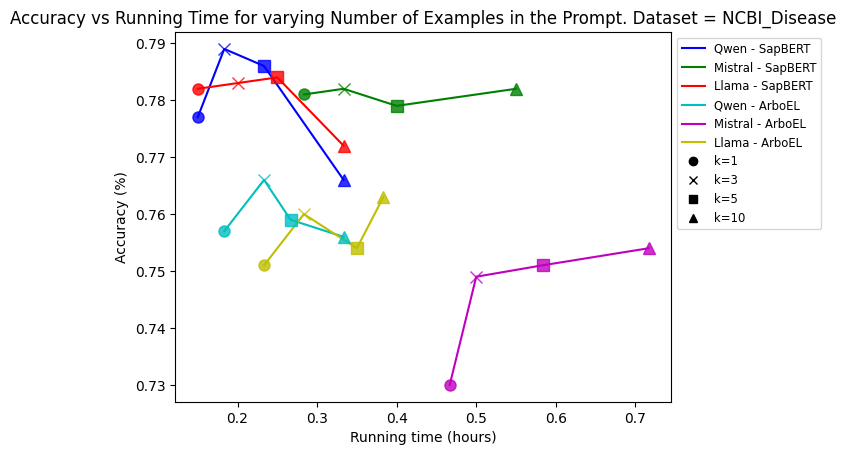

In [3]:
llama_acc_sapbert = [0.782, 0.783, 0.784, 0.772]
llama_time_sapbert = [9/60, 12/60, 15/60, 20/60]

mistral_acc_sapbert = [0.781, 0.782, 0.779, 0.782]
mistral_time_sapbert = [17/60, 20/60, 24/60, 33/60]

qwen_acc_sapbert = [0.777, 0.789, 0.786, 0.766]
qwen_time_sapbert = [9/60, 11/60, 14/60, 20/60]

llama_acc_arboel = [0.751, 0.760, 0.754, 0.763]
llama_time_arboel = [14/60, 17/60, 21/60, 23/60]

mistral_acc_arboel = [0.730, 0.749, 0.751, 0.754]
mistral_time_arboel = [28/60, 30/60, 35/60, 43/60]

qwen_acc_arboel = [0.757, 0.766, 0.759, 0.756]
qwen_time_arboel = [11/60, 14/60, 16/60, 20/60]

# Markers for each point index
markers = ['o', 'x', 's', '^']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['k=1', 'k=3', 'k=5', 'k=10']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = NCBI_Disease')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of candidates in the prompt NCBI_Disease

0
1
2
3
4
5


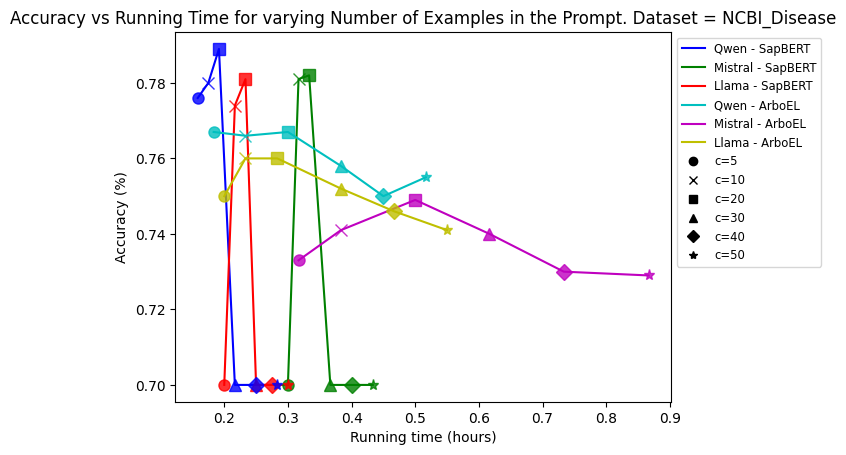

In [11]:
llama_acc_sapbert = [0.7, 0.774, 0.781, 0.7, 0.7, 0.7]
llama_time_sapbert = [12/60, 13/60, 14/60, 15/60, 16.5/60, 18/60]

mistral_acc_sapbert = [0.7, 0.781, 0.782, 0.7, 0.7, 0.7]
mistral_time_sapbert = [18/60, 19/60, 20/60, 22/60, 24/60, 26/60]

qwen_acc_sapbert = [0.776, 0.780, 0.789, 0.7, 0.7, 0.7]
qwen_time_sapbert = [9.5/60, 10.5/60, 11.5/60, 13/60, 15/60, 17/60]

llama_acc_arboel = [0.750, 0.760, 0.760, 0.752, 0.746, 0.741]
llama_time_arboel = [12/60, 14/60, 17/60, 23/60, 28/60, 33/60]

mistral_acc_arboel = [0.733, 0.741, 0.749, 0.740, 0.730, 0.729]
mistral_time_arboel = [19/60, 23/60, 30/60, 37/60, 44/60, 52/60]

qwen_acc_arboel = [0.767, 0.766, 0.767, 0.758, 0.750, 0.755]
qwen_time_arboel = [11/60, 14/60, 18/60, 23/60, 27/60, 31/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D', '*']  # Circle, cross, square, triangle, diamond, star
marker_meanings = ['c=5', 'c=10', 'c=20', 'c=30', 'c=40', 'c=50']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = NCBI_Disease')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of examples in the prompt (GNormPlus)

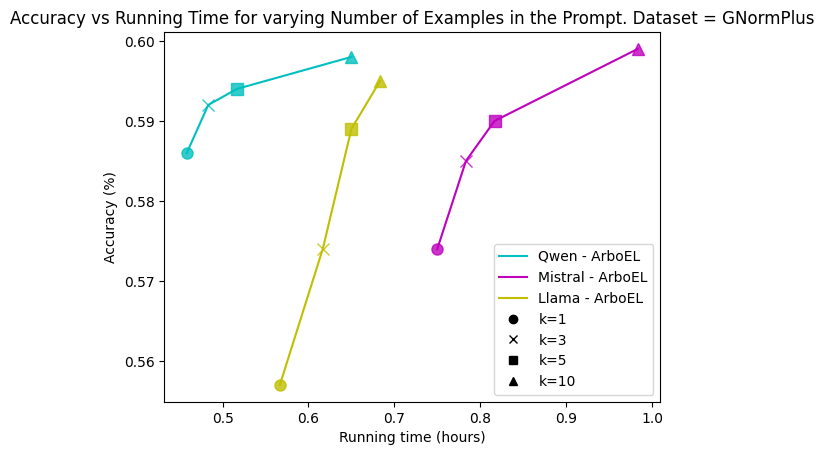

In [90]:
# llama_acc_sapbert = [0.782, 0.783, 0.784, 0.772]
# llama_time_sapbert = [9/60, 12/60, 15/60, 20/60]

# mistral_acc_sapbert = [0.781, 0.782, 0.779, 0.782]
# mistral_time_sapbert = [17/60, 20/60, 24/60, 33/60]

# qwen_acc_sapbert = [0.777, 0.789, 0.786, 0.766]
# qwen_time_sapbert = [9/60, 11/60, 14/60, 20/60]

llama_acc_arboel = [0.557, 0.574, 0.589, 0.595]
llama_time_arboel = [34/60, 37/60, 39/60, 41/60]

mistral_acc_arboel = [0.574, 0.585, 0.590, 0.599]
mistral_time_arboel = [45/60, 47/60, 49/60, 59/60]

qwen_acc_arboel = [0.586, 0.592, 0.594, 0.598]
qwen_time_arboel = [27.5/60, 29/60, 31/60, 39/60]

# Markers for each point index
markers = ['o', 'x', 's', '^']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['k=1', 'k=3', 'k=5', 'k=10']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
# ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
# ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    # ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = GNormPlus')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


## Effect of number of candidates in the prompt (GNormPlus)

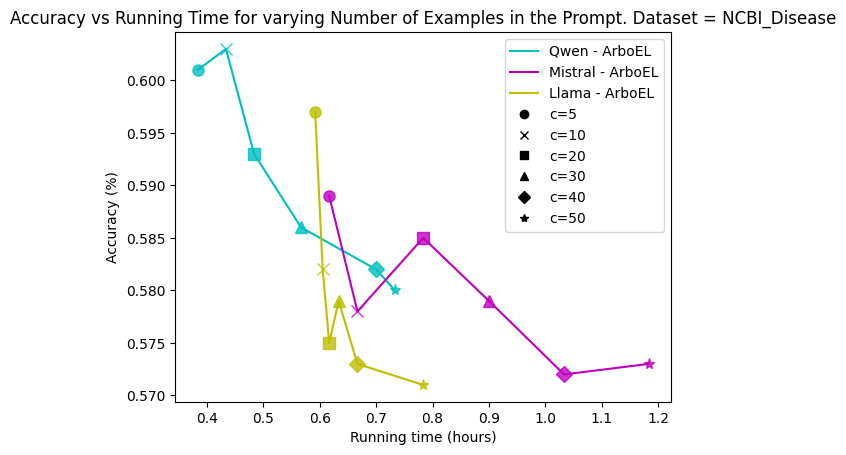

In [75]:
# llama_acc_sapbert = [0.782, 0.783, 0.784, 0.772]
# llama_time_sapbert = [9/60, 12/60, 15/60, 20/60]

# mistral_acc_sapbert = [0.781, 0.782, 0.779, 0.782]
# mistral_time_sapbert = [17/60, 20/60, 24/60, 33/60]

# qwen_acc_sapbert = [0.777, 0.789, 0.786, 0.766]
# qwen_time_sapbert = [9/60, 11/60, 14/60, 20/60]

llama_acc_arboel = [0.597, 0.582, 0.575, 0.579, 0.573, 0.571]
llama_time_arboel = [35.5/60, 36.3/60, 37/60, 38/60, 40/60, 47/60]

mistral_acc_arboel = [0.589, 0.578, 0.585, 0.579, 0.572, 0.573]
mistral_time_arboel = [37/60, 40/60, 47/60, 54/60, 62/60, 71/60]

qwen_acc_arboel = [0.601, 0.603, 0.593, 0.586, 0.582, 0.580]
qwen_time_arboel = [23/60, 26/60, 29/60, 34/60, 42/60, 44/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D', '*']  # Circle, cross, square, triangle, diamond, star
marker_meanings = ['c=5', 'c=10', 'c=20', 'c=30', 'c=40', 'c=50']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
# ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
# ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    # ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    # ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = NCBI_Disease')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


## Number of mentions vs running time for the different models

In [23]:
path = "data/medmentions_st21pv/sapbert/accuracy/Qwen2.5-7B-Instruct_k=3_cands=10_recall=False5_true_results.json"
with open(
    path, "r"
) as f:
    results = json.load(f)
len(results)


31827

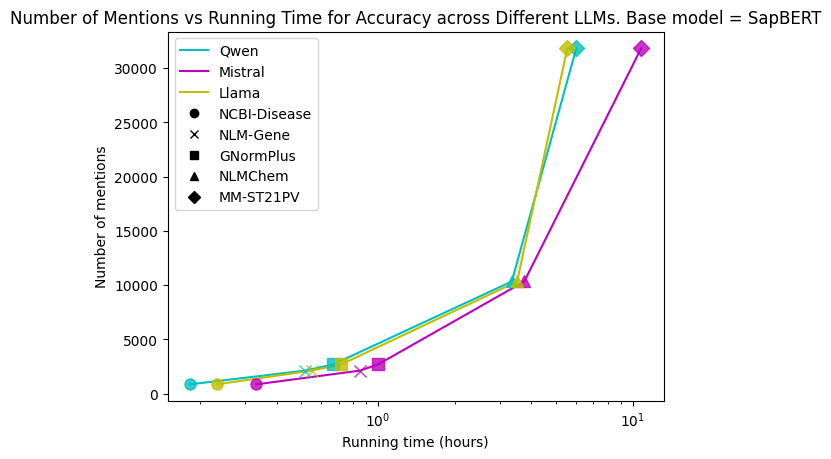

In [39]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

# gpt4o_mini_time_sapbert = [11/60, 38/60, 70/60, 2 + 20/60]

# gpt4o_time_sapbert = [12/60, 28/60, 39/60, 2 + 10/60]

llama_time_sapbert = [14/60, 33/60, 43/60, 3 + 31/60, 5 + 32/60]

mistral_time_sapbert = [20/60, 51/60, 60/60, 3 + 45/60, 10 + 47/60]

qwen_time_sapbert = [11/60, 31/60, 40/60, 3 + 21/60, 6 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(qwen_time_sapbert, X, color=colors[3], linestyle='-', label='Qwen')
ax.plot(mistral_time_sapbert, X, color=colors[4], linestyle='-', label='Mistral')
ax.plot(llama_time_sapbert, X, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_sapbert[i], X[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], X[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], X[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Number of mentions')
ax.set_title('Number of Mentions vs Running Time for Accuracy across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
ax.set_xscale('log')
# ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


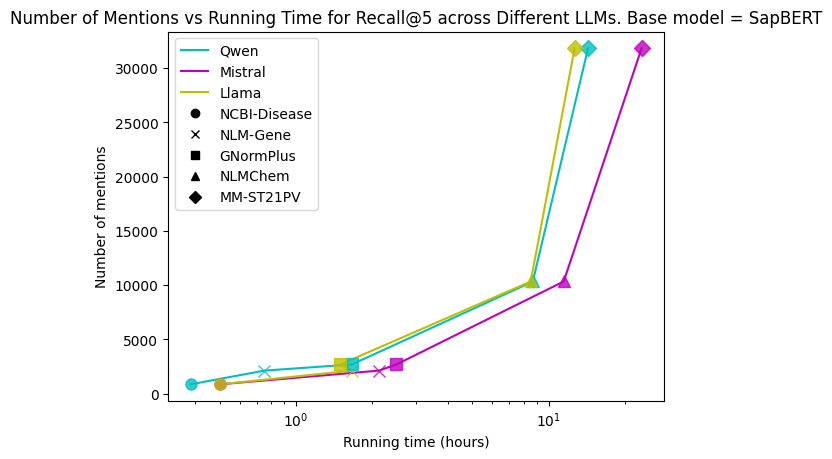

In [40]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

llama_time_sapbert = [30/60, 1 + 40/60, 1 + 30/60, 3 + 5 + 30/60, 12 + 41/60]

mistral_time_sapbert = [30/60, 2 + 8/60, 2 + 30/60, 3 + 8 + 29/60, 23 + 21/60]

qwen_time_sapbert = [23/60, 45/60, 1 + 40/60, 3 + 5 + 40/60, 14 + 20/60]

# gpt4o_mini_time_sapbert = [13/60, 45/60, 1 + 30/60, 4 + 0/60]

# gpt4o_time_sapbert = [16/60, 41/60, 55/60, 4 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(qwen_time_sapbert, X, color=colors[3], linestyle='-', label='Qwen')
ax.plot(mistral_time_sapbert, X, color=colors[4], linestyle='-', label='Mistral')
ax.plot(llama_time_sapbert, X, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_sapbert[i], X[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], X[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], X[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Number of mentions')
ax.set_title('Number of Mentions vs Running Time for Recall@5 across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
ax.set_xscale('log')
# ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


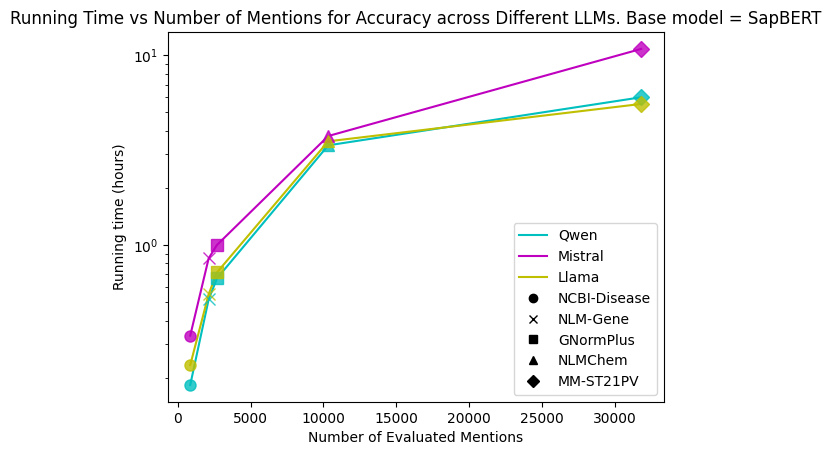

In [43]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

# gpt4o_mini_time_sapbert = [11/60, 38/60, 70/60, 2 + 20/60]

# gpt4o_time_sapbert = [12/60, 28/60, 39/60, 2 + 10/60]

llama_time_sapbert = [14/60, 33/60, 43/60, 3 + 31/60, 5 + 32/60]

mistral_time_sapbert = [20/60, 51/60, 60/60, 3 + 45/60, 10 + 47/60]

qwen_time_sapbert = [11/60, 31/60, 40/60, 3 + 21/60, 6 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(X, qwen_time_sapbert, color=colors[3], linestyle='-', label='Qwen')
ax.plot(X, mistral_time_sapbert, color=colors[4], linestyle='-', label='Mistral')
ax.plot(X, llama_time_sapbert, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], qwen_time_sapbert[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], mistral_time_sapbert[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], llama_time_sapbert[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Number of Evaluated Mentions')
ax.set_ylabel('Running time (hours)')
ax.set_title('Running Time vs Number of Mentions for Accuracy across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
# ax.set_xscale('log')
ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


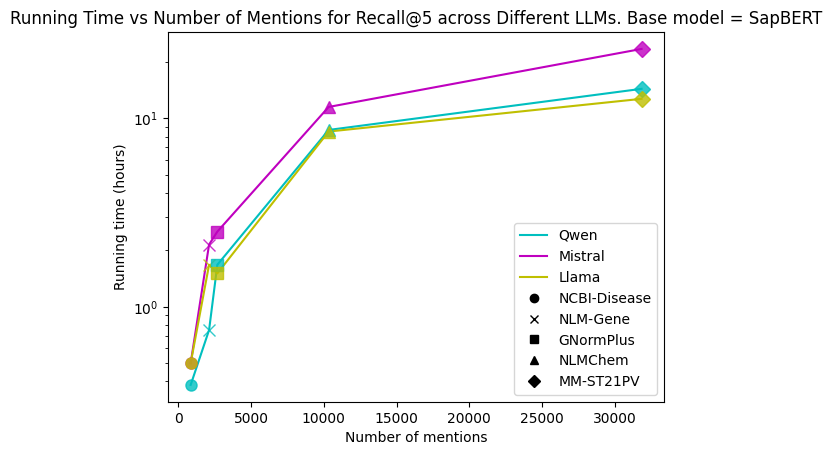

In [42]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

llama_time_sapbert = [30/60, 1 + 40/60, 1 + 30/60, 3 + 5 + 30/60, 12 + 41/60]

mistral_time_sapbert = [30/60, 2 + 8/60, 2 + 30/60, 3 + 8 + 29/60, 23 + 21/60]

qwen_time_sapbert = [23/60, 45/60, 1 + 40/60, 3 + 5 + 40/60, 14 + 20/60]

# gpt4o_mini_time_sapbert = [13/60, 45/60, 1 + 30/60, 4 + 0/60]

# gpt4o_time_sapbert = [16/60, 41/60, 55/60, 4 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(X, qwen_time_sapbert, color=colors[3], linestyle='-', label='Qwen')
ax.plot(X, mistral_time_sapbert, color=colors[4], linestyle='-', label='Mistral')
ax.plot(X, llama_time_sapbert, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], qwen_time_sapbert[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], mistral_time_sapbert[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], llama_time_sapbert[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Number of Evaluated Mentions')
ax.set_ylabel('Running time (hours)')
ax.set_title('Running Time vs Number of Mentions for Recall@5 across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
# ax.set_xscale('log')
ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


# Deprecated
# vllm + aqlm 


In [ ]:
llm = LLM(
    model="ISTA-DASLab/Mixtral-8x7B-Instruct-v0_1-AQLM-2Bit-1x16-hf",
    enforce_eager=True,
)

tokenizer = llm.get_tokenizer()

In [30]:
# def prompt_vllm_aqlm(mention, context, system_instructions, candidates, topk_examples, llm, tokenizer, sampling_params):
#     ''' 
#     mention : str (name of the mention to be linked)
#     context : str (context where the mention appears)
#     system_instructions : str (instructions for the LLM)
#     candidates : list of list of CUIs : [[cui1], [cui2, cui3], ...]
#     topk_examples : str (top k examples of similar contexts)
#     llm : LLM model
#     tokenizer : AutoTokenizer
#     sampling_params : SamplingParams config
#     '''
    
#     prompt_text = f"""
#     System Instructions: {system_instructions} \n
    
#     Here are a few examples: \n
#     {topk_examples} \n

#     This is the specific mention that needs to be linked to the correct entity: {mention} \n

#     This is the context where the mention appears: \n
#     {context} \n
    
#     These are the candidate entities to choose from: \n
#     {candidates} \n
    
#     You MUST PROVIDE an ANSWER among the candidates. \n

#     Return the answer in the following format: CUI
#     For instance : "MESH:D000000" "OMIM:000000" are valid answers. \n
#     Do not add provide any explanations ! But you MUST give ONE answer.
#     """
#     conversations = tokenizer.apply_chat_template(
#         [{'role': 'user', 'content': prompt_text}],
#         tokenize=False,
#     )

#     # Decode the generated tokens into text
#     outputs = llm.generate([conversations], sampling_params=sampling_params, use_tqdm=False)
#     answer = outputs[0].outputs[0].text

#     return answer


In [ ]:
mention = "9931324.1"
text = mention2text[mention]
context = mention2context[mention]
candidates = get_candidates_data(mention2biencoder_candidates[mention], ontology2)
topk = topk_examples(model = model,
                    index = index,
                    query=context, 
                    corpus=corpus, 
                    TrainMap_context2mention=TrainMap_context2mention, 
                    train_mention2text=train_mention2text, 
                    train_mention2gold=train_mention2gold, 
                    ontology=ontology2, 
                    k=3)

pred_cui = prompt_vllm_aqlm(mention=text, 
                       context=context, 
                       system_instructions=system_instructions,
                       candidates=candidates, 
                       topk_examples=topk,
                       llm=llm,
                       tokenizer=tokenizer,
                       sampling_params=sampling_params)

# Output the results
print("Mention ID:", mention)
print("Context:", context)
print("Top k examples:", topk)
print("Text:", mention2text[mention])
print("Gold CUI:", mention2gold[mention])
print("Predicted CUI:", pred_cui)

In [44]:
# def evaluate_vllm_aqlm(
#     llm,
#     nlp_model,
#     tokenizer,
#     index,
#     system_instructions,
#     mentions,
#     ontology,
#     corpus,
#     mention2context,
#     mention2biencoder_candidates,
#     mention2text,
#     TrainMap_context2mention,
#     train_mention2text,
#     train_mention2gold,
#     k,
#     sampling_params,
# ):
#     """
#     Run "prompt" function for each mention in the list of mentions.
#     Returns a dictionary {mention_id : predicted CUI}
#     -------
#     llm : LLM model
#     nlp_model : SentenceTransformer model
#     tokenizer : AutoTokenizer
#     index : faiss index
#     system_instructions : str (instructions for the LLM)
#     mentions : list (mention_ids)
#     ontology : BiomedicalOntology object
#     corpus : list of str (all context sentences)
#     mention2context : dict (mention_id : context)
#     mention2biencoder_candidates : dict (mention_id : list of candidate CUIs)
#     mention2text : dict (mention_id : mention name)
#     TrainMap_context2mention : dict (context sentence to mention_id)
#     train_mention2text : dict (mention_id to mention name)
#     train_mention2gold : dict (mention_id to gold CUI)
#     k : int (number of nearest neighbors)
#     sampling_params : SamplingParams config
#     """
#     results = {}
#     for i in range(len(mentions)) :
#         mention_id = mentions[i]
#         mention_name = mention2text[mention_id]
#         context = mention2context[mention_id]
#         candidates = get_candidates_data(mention2biencoder_candidates[mentions[i]], ontology)
#         # candidates = get_candidates_data_v2(mention2arboel_candidates[mention])
#         topk = topk_examples(
#             model=nlp_model,  # sentence transformer model
#             index=index,
#             query=context,
#             corpus=corpus,
#             TrainMap_context2mention=TrainMap_context2mention,
#             train_mention2text=train_mention2text,
#             train_mention2gold=train_mention2gold,
#             ontology=ontology,
#             k=k,
#         )
#         text = prompt_vllm_aqlm(
#             mention=mention_name,
#             context=context,
#             system_instructions=system_instructions,
#             candidates=candidates,
#             topk_examples=topk,
#             llm=llm,
#             tokenizer=tokenizer,
#             sampling_params=sampling_params,
#         )
#         print("mention ID :", mention_id , "|| LLM answer :", text)
#         cand = extract_cui(text)
#         results[mention_id] = cand
#         if i%20 == 0:
#             print(f"i = {i}")

#     return results
    


In [ ]:
results = evaluate_vllm_aqlm(llm=llm,
                        nlp_model=model,
                        tokenizer=tokenizer,
                        index=index,
                        system_instructions=system_instructions,
                        mentions=mentions[:5],
                        ontology=ontology2,
                        corpus=corpus,
                        mention2context=mention2context,
                        mention2biencoder_candidates=mention2biencoder_candidates,
                        mention2text=mention2text,
                        TrainMap_context2mention=TrainMap_context2mention,
                        train_mention2text=train_mention2text,
                        train_mention2gold=train_mention2gold,
                        k=10,
                        sampling_params=sampling_params)
results

In [ ]:
results

In [ ]:
score = scoring(results=results, mention2gold=mention2gold)
score